In [1]:
from XSpect import Pipeline
import numpy as np
import matplotlib.pyplot as plt

p = Pipeline.from_yaml('examples/xcs101591326_ultrafast_xas.yaml')
p.run(cores=1, batch_size=100000)

# Aggregate stats across all runs
# Runs may have different numbers of energy bins (incomplete scans) — use union grid size
union_energies = np.unique(np.round(
    np.concatenate([run.ccm_energies for run in p.analyzed_runs]), 5))
n_bins    = len(union_energies)
total_on  = sum(run.epix_simultaneous_laser_energy_bincount.sum() for run in p.analyzed_runs)
total_off = sum(run.epix_xray_not_laser_energy_bincount.sum()     for run in p.analyzed_runs)

print(f'Runs processed: {len(p.analyzed_runs)}')
print(f'Energy bins (union): {n_bins}')
print(f'Total shots (laser-on): {total_on:.0f}')
print(f'Total shots (laser-off): {total_off:.0f}')
print(f'Avg shots/bin (laser-on): {total_on / n_bins:.0f}')
print(f'Avg shots/bin (laser-off): {total_off / n_bins:.0f}')

Runs processed: 30
Energy bins (union): 41
Total shots (laser-on): 280260
Total shots (laser-off): 288262
Avg shots/bin (laser-on): 6836
Avg shots/bin (laser-off): 7031


Aggregated 30 runs onto 41 energy points
Total shots: laser-on=280260, laser-off=288262


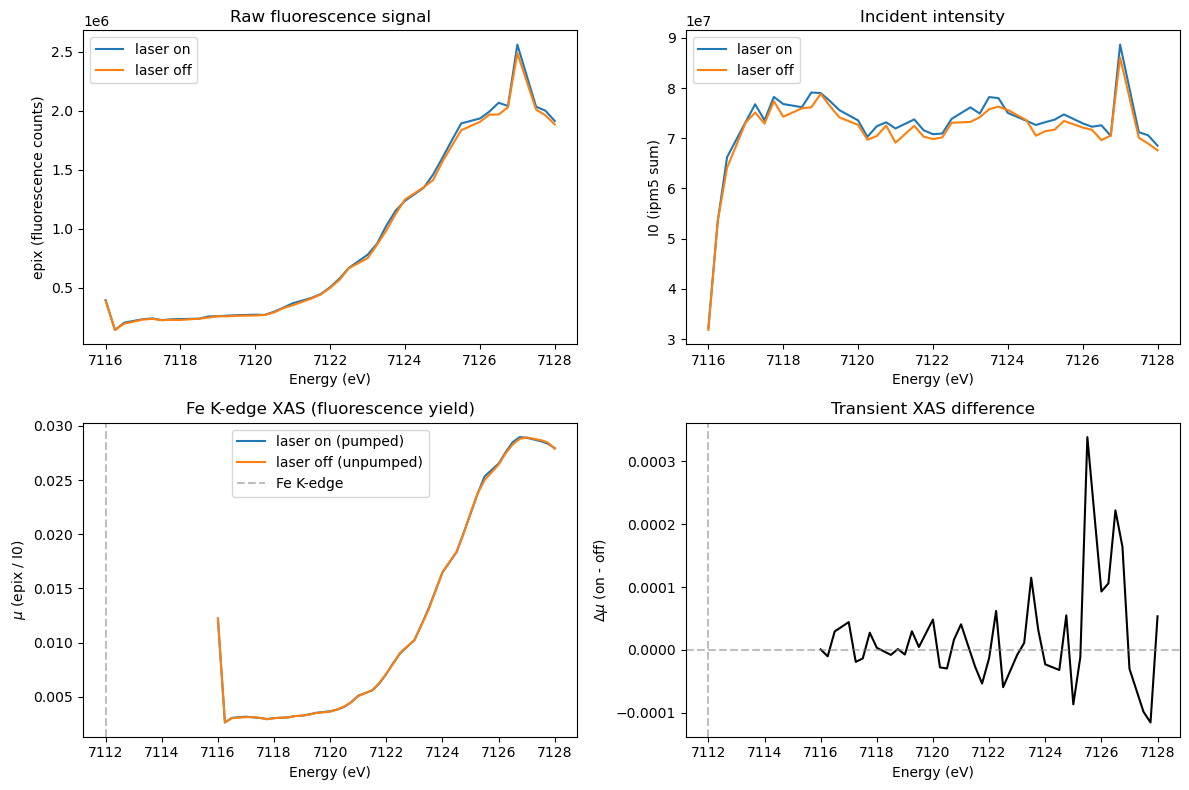

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Build union energy grid — runs may have incomplete scans with different bin counts.
# Round to 5 decimal places (keV) = 0.01 eV precision to avoid float comparison issues.
union_energies = np.unique(np.round(
    np.concatenate([run.ccm_energies for run in p.analyzed_runs]), 5))
energy = union_energies * 1000  # keV -> eV
n_union = len(union_energies)

epix_on   = np.zeros(n_union)
I0_on     = np.zeros(n_union)
epix_off  = np.zeros(n_union)
I0_off    = np.zeros(n_union)
counts_on  = np.zeros(n_union)
counts_off = np.zeros(n_union)

for run in p.analyzed_runs:
    e_run = np.round(run.ccm_energies, 5)
    n = len(e_run)
    # Map this run's energy points onto the union grid by exact position
    idx = np.searchsorted(union_energies, e_run)
    epix_on[idx]    += run.epix_simultaneous_laser_energy_binned[:n]
    I0_on[idx]      += run.ipm_simultaneous_laser_energy_binned[:n]
    epix_off[idx]   += run.epix_xray_not_laser_energy_binned[:n]
    I0_off[idx]     += run.ipm_xray_not_laser_energy_binned[:n]
    counts_on[idx]  += run.epix_simultaneous_laser_energy_bincount[:n]
    counts_off[idx] += run.epix_xray_not_laser_energy_bincount[:n]

print(f'Aggregated {len(p.analyzed_runs)} runs onto {n_union} energy points')
print(f'Total shots: laser-on={counts_on.sum():.0f}, laser-off={counts_off.sum():.0f}')

# Fluorescence-yield XAS: mu ∝ If / I0
safe_I0_on = np.where(I0_on > 0, I0_on, np.nan)
safe_I0_off = np.where(I0_off > 0, I0_off, np.nan)

mu_on = epix_on / safe_I0_on
mu_off = epix_off / safe_I0_off
diff = mu_on - mu_off

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top-left: raw fluorescence counts
ax = axes[0, 0]
ax.plot(energy, epix_on, label='laser on')
ax.plot(energy, epix_off, label='laser off')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('epix (fluorescence counts)')
ax.set_title('Raw fluorescence signal')
ax.legend()

# Top-right: I0 per energy bin
ax = axes[0, 1]
ax.plot(energy, I0_on, label='laser on')
ax.plot(energy, I0_off, label='laser off')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('I0 (ipm5 sum)')
ax.set_title('Incident intensity')
ax.legend()

# Bottom-left: normalized XAS (If/I0)
ax = axes[1, 0]
ax.plot(energy, mu_on, label='laser on (pumped)')
ax.plot(energy, mu_off, label='laser off (unpumped)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel(r'$\mu$ (epix / I0)')
ax.set_title('Fe K-edge XAS (fluorescence yield)')
ax.axvline(7112, color='gray', ls='--', alpha=0.5, label='Fe K-edge')
ax.legend()

# Bottom-right: difference spectrum
ax = axes[1, 1]
ax.plot(energy, diff, 'k-')
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.axvline(7112, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel(r'$\Delta\mu$ (on - off)')
ax.set_title('Transient XAS difference')

plt.tight_layout()
plt.show()

In [3]:
# ── Diagnostic: bin-by-bin coverage ─────────────────────────────────────────
# Flags NaN bins and distinguishes the three possible gap causes:
#   A) counts_on==0, counts_off==0  → energies not scanned (or CCM missed)
#   B) counts_on==0, counts_off>0   → laser was OFF at those energies
#                                     (or ipm threshold removed all laser-on shots)
#   C) counts_on>0, counts_off==0   → no xray-not-laser reference

header = f"{'Energy':>10} {'shots_on':>10} {'shots_off':>11} {'I0_on':>12} {'I0_off':>12}  mu_on    mu_off  note"
print(header)
print('-' * 95)
for i, e in enumerate(energy):
    mon  = f'{mu_on[i]:.4f}'  if not np.isnan(mu_on[i])  else 'NaN    '
    moff = f'{mu_off[i]:.4f}' if not np.isnan(mu_off[i]) else 'NaN    '
    if counts_on[i] == 0 and counts_off[i] == 0:
        note = '<-- A: not scanned'
    elif counts_on[i] == 0:
        note = '<-- B: no laser-on shots'
    elif counts_off[i] == 0:
        note = '<-- C: no laser-off shots'
    else:
        note = ''
    print(f'{e:10.2f} {int(counts_on[i]):10} {int(counts_off[i]):11} '
          f'{I0_on[i]:12.1f} {I0_off[i]:12.1f}  {mon}  {moff}  {note}')

print()
print(f'NaN bins  — mu_on: {np.sum(np.isnan(mu_on))}, mu_off: {np.sum(np.isnan(mu_off))}')
print(f'Zero bins — shots_on: {int(np.sum(counts_on==0))}, shots_off: {int(np.sum(counts_off==0))}')

# Also print the ipm threshold from the YAML to remind us what we're filtering at
print()
print('Reminder: filter_shots threshold = 500 (ipm5/sum). '
      'Bins where ALL simultaneous shots have ipm<500 will show as type B.')


    Energy   shots_on   shots_off        I0_on       I0_off  mu_on    mu_off  note
-----------------------------------------------------------------------------------------------
   7116.00       4976        7175   32235465.6   31804549.8  0.0122  0.0122  
   7116.25       6929        7180   53423601.4   53496168.9  0.0026  0.0027  
   7116.50       6858        7177   66236846.9   64124028.5  0.0031  0.0030  
   7117.00       7047        7186   73281136.6   73168684.4  0.0032  0.0031  
   7117.25       7038        7180   76760037.0   75112387.0  0.0031  0.0031  
   7117.50       6926        7055   73567276.8   72911823.6  0.0031  0.0031  
   7117.75       6840        6945   78224283.6   77370889.0  0.0030  0.0029  
   7118.00       6837        6946   76807722.5   74282901.1  0.0030  0.0030  
   7118.50       6794        6934   76175839.0   75959032.8  0.0031  0.0031  
   7118.75       6848        6945   79101132.6   76153765.9  0.0032  0.0032  
   7119.00       6810        6915   78995

In [4]:
union_energies

array([7.116  , 7.11625, 7.1165 , 7.117  , 7.11725, 7.1175 , 7.11775,
       7.118  , 7.1185 , 7.11875, 7.119  , 7.11925, 7.1195 , 7.12   ,
       7.12025, 7.1205 , 7.12075, 7.121  , 7.1215 , 7.12175, 7.122  ,
       7.12225, 7.1225 , 7.123  , 7.12325, 7.1235 , 7.12375, 7.124  ,
       7.1245 , 7.12475, 7.125  , 7.12525, 7.1255 , 7.126  , 7.12625,
       7.1265 , 7.12675, 7.127  , 7.1275 , 7.12775, 7.128  ])

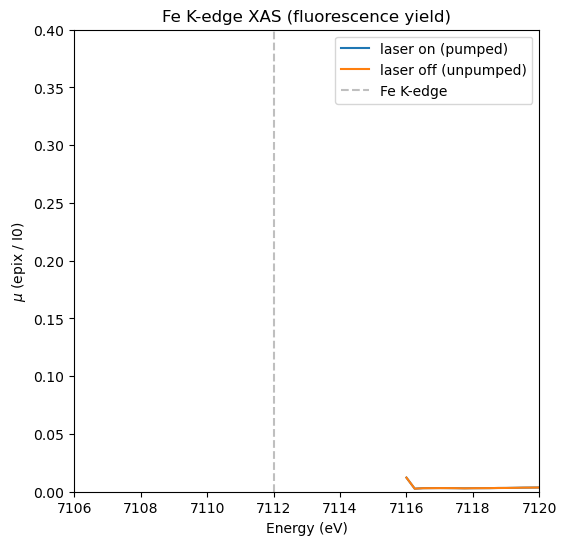

In [5]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))

ax = axes
ax.plot(energy, mu_on,'-', label='laser on (pumped)')
ax.plot(energy, mu_off,'-', label='laser off (unpumped)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel(r'$\mu$ (epix / I0)')
ax.set_title('Fe K-edge XAS (fluorescence yield)')
ax.axvline(7112, color='gray', ls='--', alpha=0.5, label='Fe K-edge')
ax.set_xlim(7106,7120)
ax.set_ylim(0,0.4)
ax.legend()



(-0.01, 0.01)

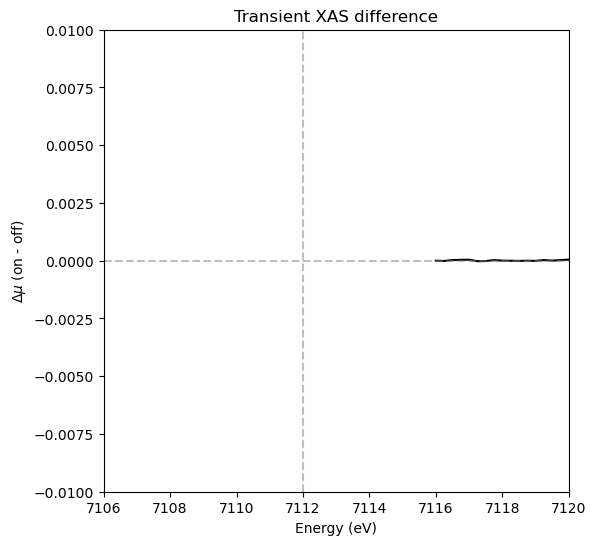

In [6]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
ax = axes
ax.plot(energy, diff, 'k-')
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.axvline(7112, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel(r'$\Delta\mu$ (on - off)')
ax.set_title('Transient XAS difference')
ax.set_xlim(7106,7120)
ax.set_ylim(-0.01,0.01)

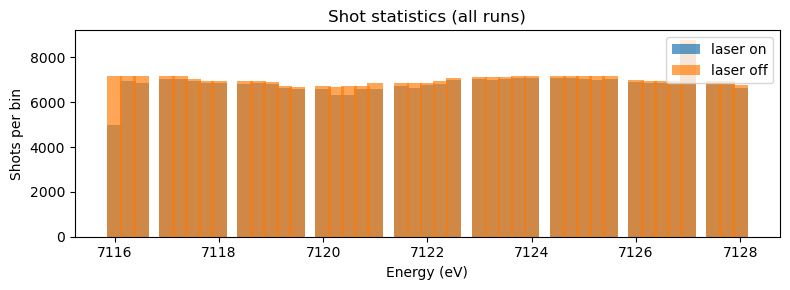

In [7]:
# Shot statistics per energy bin (aggregated)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(energy, counts_on, width=0.3, alpha=0.7, label='laser on')
ax.bar(energy, counts_off, width=0.3, alpha=0.7, label='laser off')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Shots per bin')
ax.set_title('Shot statistics (all runs)')
ax.legend()
plt.tight_layout()
plt.show()

Runs processed: 1
Time bins: 14 (-40 to 100 ps)
Total shots: laser-on=9168, laser-off=3677
Dark reference (avg laser-off mu): 0.004814


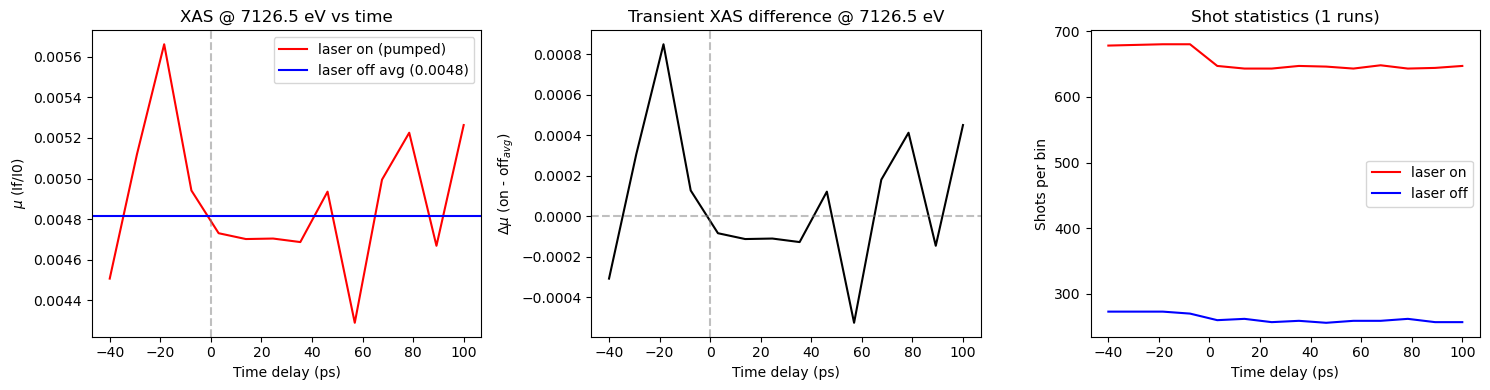

In [8]:
# Temporal XAS: fluorescence yield vs time delay (runs 81-89, fixed energy 7126.5 eV)
from XSpect import Pipeline
import numpy as np
import matplotlib.pyplot as plt

p_time = Pipeline.from_yaml('examples/xcs101591326_temporal_xas.yaml')
p_time.run(cores=1, batch_size=100000000)

print(f'Runs processed: {len(p_time.analyzed_runs)}')

# Aggregate time-binned data across all runs (same time bins for all)
time_ps = p_time.analyzed_runs[0].time_bins
n_time = len(time_ps)

epix_on = np.zeros(n_time)
ipm_on = np.zeros(n_time)
epix_off = np.zeros(n_time)
ipm_off = np.zeros(n_time)
counts_on = np.zeros(n_time)
counts_off = np.zeros(n_time)

for run in p_time.analyzed_runs:
    epix_on += run.epix_simultaneous_laser_time_binned[:n_time]
    ipm_on += run.ipm_simultaneous_laser_time_binned[:n_time]
    epix_off += run.epix_xray_not_laser_time_binned[:n_time]
    ipm_off += run.ipm_xray_not_laser_time_binned[:n_time]
    counts_on += run.epix_simultaneous_laser_bincount[:n_time]
    counts_off += run.epix_xray_not_laser_bincount[:n_time]

# Fluorescence-yield XAS: mu = If / I0
safe_ipm_on = np.where(ipm_on > 0, ipm_on, np.nan)
safe_ipm_off = np.where(ipm_off > 0, ipm_off, np.nan)
mu_on = epix_on / safe_ipm_on
mu_off = epix_off / safe_ipm_off

# Use the average of ALL laser-off time bins as the dark reference
mu_off_avg = np.nanmean(mu_off)
delta_mu = mu_on - mu_off_avg

print(f'Time bins: {n_time} ({time_ps[0]:.0f} to {time_ps[-1]:.0f} ps)')
print(f'Total shots: laser-on={counts_on.sum():.0f}, laser-off={counts_off.sum():.0f}')
print(f'Dark reference (avg laser-off mu): {mu_off_avg:.6f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(time_ps, mu_on, 'r-', label='laser on (pumped)')
ax.axhline(mu_off_avg, color='b', ls='-', label=f'laser off avg ({mu_off_avg:.4f})')
ax.set_xlabel('Time delay (ps)')
ax.set_ylabel(r'$\mu$ (If/I0)')
ax.set_title('XAS @ 7126.5 eV vs time')
ax.axvline(0, color='gray', ls='--', alpha=0.5)
ax.legend()

ax = axes[1]
ax.plot(time_ps, delta_mu, 'k-')
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.axvline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Time delay (ps)')
ax.set_ylabel(r'$\Delta\mu$ (on - off$_{avg}$)')
ax.set_title('Transient XAS difference @ 7126.5 eV')

ax = axes[2]
ax.plot(time_ps, counts_on, 'r-', label='laser on')
ax.plot(time_ps, counts_off, 'b-', label='laser off')
ax.set_xlabel('Time delay (ps)')
ax.set_ylabel('Shots per bin')
ax.set_title(f'Shot statistics ({len(p_time.analyzed_runs)} runs)')
ax.legend()

plt.tight_layout()
plt.show()

In [9]:
np.nansum(counts_on)/120

76.4

Runs: 30  |  Energy bins: 41  |  Time bins: 21 (-2.0 to 8.0 ps)


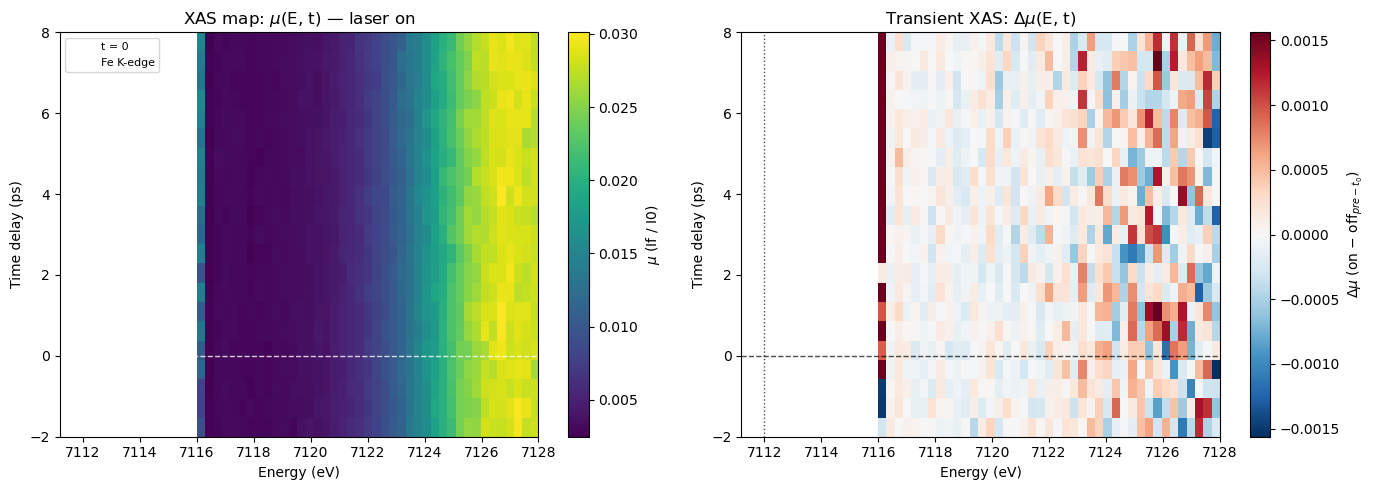

In [10]:
# ── 2D XAS: DCCM energy × time delay ─────────────────────────────────────────
from XSpect import Pipeline
import numpy as np
import matplotlib.pyplot as plt

p2d = Pipeline.from_yaml('examples/xcs101591326_2d_xas.yaml')
p2d.run(cores=1, batch_size=100000)

# ── Aggregate across runs ─────────────────────────────────────────────────────
# Energy: union grid (runs may have incomplete scans)
union_energies = np.unique(np.round(
    np.concatenate([run.ccm_energies for run in p2d.analyzed_runs]), 5))
energy_2d = union_energies * 1000  # keV -> eV
n_energy = len(union_energies)

# Time: fixed axis (all runs share the same linspace bins)
time_ps = p2d.analyzed_runs[0].time_bins
n_time = len(time_ps)

epix_on_2d  = np.zeros((n_time, n_energy))
I0_on_2d    = np.zeros((n_time, n_energy))
epix_off_2d = np.zeros((n_time, n_energy))
I0_off_2d   = np.zeros((n_time, n_energy))

for run in p2d.analyzed_runs:
    e_run = np.round(run.ccm_energies, 5)
    n_e   = len(e_run)
    e_idx = np.searchsorted(union_energies, e_run)
    epix_on_2d[:, e_idx]  += run.epix_simultaneous_laser_time_energy_binned[:n_time, :n_e]
    I0_on_2d[:, e_idx]    += run.ipm_simultaneous_laser_time_energy_binned[:n_time, :n_e]
    epix_off_2d[:, e_idx] += run.epix_xray_not_laser_time_energy_binned[:n_time, :n_e]
    I0_off_2d[:, e_idx]   += run.ipm_xray_not_laser_time_energy_binned[:n_time, :n_e]

# ── Fluorescence yield ────────────────────────────────────────────────────────
safe_I0_on  = np.where(I0_on_2d  > 0, I0_on_2d,  np.nan)
safe_I0_off = np.where(I0_off_2d > 0, I0_off_2d, np.nan)
mu_on_2d  = epix_on_2d  / safe_I0_on
mu_off_2d = epix_off_2d / safe_I0_off

# Δμ: subtract pre-t0 laser-off average as reference (shape: 1 × n_energy)
pre_t0 = time_ps < 0
mu_ref     = np.nanmean(mu_off_2d[pre_t0, :], axis=0, keepdims=True)
delta_mu   = mu_on_2d - mu_ref

print(f'Runs: {len(p2d.analyzed_runs)}  |  '
      f'Energy bins: {n_energy}  |  '
      f'Time bins: {n_time} ({time_ps[0]:.1f} to {time_ps[-1]:.1f} ps)')

# ── Plot ──────────────────────────────────────────────────────────────────────
extent = [energy_2d[0], energy_2d[-1], time_ps[0], time_ps[-1]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute μ(E, t) laser-on
ax = axes[0]
im = ax.imshow(mu_on_2d, aspect='auto', origin='lower', extent=extent)
plt.colorbar(im, ax=ax, label=r'$\mu$ (If / I0)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Time delay (ps)')
ax.set_title(r'XAS map: $\mu$(E, t) — laser on')
ax.axhline(0, color='w', ls='--', lw=1, alpha=0.8, label='t = 0')
ax.axvline(7112, color='w', ls=':', lw=1, alpha=0.8, label='Fe K-edge')
ax.legend(fontsize=8, loc='upper left')

# Right: Δμ(E, t) = μ_on − μ_off(pre-t0)
ax = axes[1]
vmax = np.nanpercentile(np.abs(delta_mu), 98)
im2 = ax.imshow(delta_mu, aspect='auto', origin='lower', extent=extent,
                cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im2, ax=ax, label=r'$\Delta\mu$ (on $-$ off$_{pre-t_0}$)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Time delay (ps)')
ax.set_title(r'Transient XAS: $\Delta\mu$(E, t)')
ax.axhline(0, color='k', ls='--', lw=1, alpha=0.7)
ax.axvline(7112, color='k', ls=':', lw=1, alpha=0.7)

plt.tight_layout()
plt.show()
